In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences

# disable TF noise
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# set random seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# directories
DATA_RAW_DIR       = "data/raw"
DATA_PROCESSED_DIR = "data/processed"
FIGURES_DIR        = "outputs/figures"
MODELS_DIR         = "outputs/models"
RESULTS_DIR        = "results"

for d in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

2025-04-30 20:10:57.934394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-30 20:10:58.357442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746058258.516139 1256335 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746058258.556196 1256335 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746058258.916471 1256335 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [27]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

In [18]:
# load iyer dataset
raw_path = os.path.join(DATA_RAW_DIR, "iyer.txt")

# tab-delimited; some rows might have leading/trailing spaces
df = pd.read_csv(raw_path, delimiter="\t", header=None)
df.columns = ["gene_id", "label"] + [f"f{i}" for i in range(df.shape[1] - 2)]

# remove outliers
df = df[df["label"] != -1].reset_index(drop=True)

# extract features and labels
X = df.drop(columns=["gene_id", "label"]).astype(float).values
y = df["label"].astype(int).values

print(f"X shape: {X.shape} | y shape: {y.shape}")
print(f"Unique classes: {np.unique(y)}")

X shape: (484, 12) | y shape: (484,)
Unique classes: [ 1  2  3  4  5  6  7  8  9 10]


In [19]:
# reserve 10% as test set (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test shape:  {X_test.shape},  y_test:  {y_test.shape}")

X_train shape: (435, 12), y_train: (435,)
X_test shape:  (49, 12),  y_test:  (49,)


In [20]:
# save the data
np.savez_compressed(os.path.join(DATA_PROCESSED_DIR, "train.npz"), x=X_train, y=y_train)
np.savez_compressed(os.path.join(DATA_PROCESSED_DIR, "test.npz"), x=X_test, y=y_test)

In [88]:
# load the data
train_npz = np.load(os.path.join(DATA_PROCESSED_DIR, "train.npz"))
test_npz  = np.load(os.path.join(DATA_PROCESSED_DIR, "test.npz"))

X_train = train_npz["x"]
y_train = train_npz["y"]
X_test  = test_npz["x"]
y_test  = test_npz["y"]

print(f"Loaded X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Loaded X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Loaded X_train: (435, 12), y_train: (435,)
Loaded X_test:  (49, 12),  y_test:  (49,)


In [89]:
# fit scaler only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [90]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = to_categorical(le.fit_transform(y_train))
y_test_encoded  = to_categorical(le.transform(y_test))

NUM_CLASSES = y_train_encoded.shape[1]
class_names = [str(c) for c in le.classes_]

print(f"y_train_encoded shape: {y_train_encoded.shape}")
print(f"y_test_encoded shape:  {y_test_encoded.shape}")
print(f"Class mapping: {class_names}")

y_train_encoded shape: (435, 10)
y_test_encoded shape:  (49, 10)
Class mapping: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']


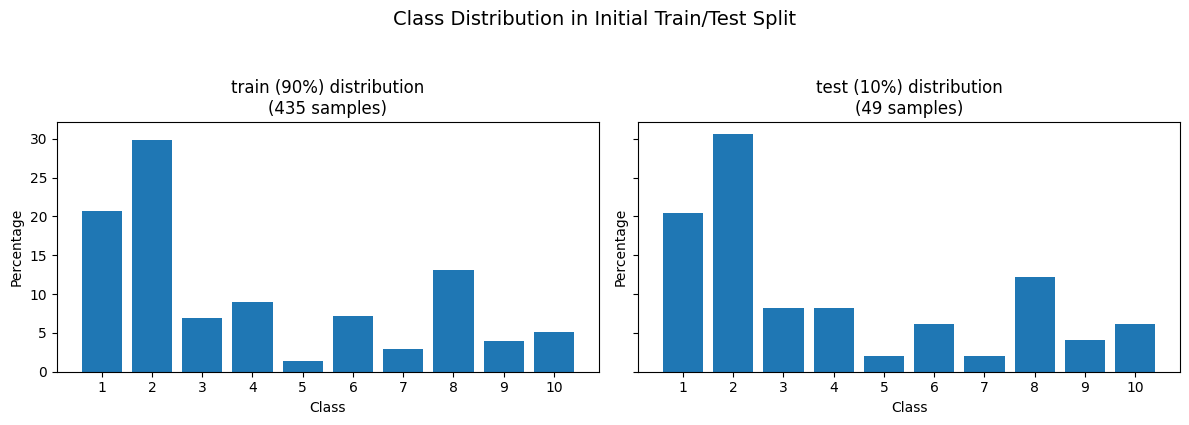

In [91]:
train_counts = np.bincount(le.transform(y_train), minlength=NUM_CLASSES)
test_counts  = np.bincount(le.transform(y_test),  minlength=NUM_CLASSES)

train_pct = train_counts / train_counts.sum() * 100
test_pct  = test_counts  / test_counts.sum()  * 100

split_info = [
    ("train (90%)", train_counts.sum()),
    ("test (10%)",  test_counts.sum())
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, pct, (title, count) in zip(axes, [train_pct, test_pct], split_info):
    ax.bar(range(NUM_CLASSES), pct)
    ax.set_title(f"{title} distribution\n({count} samples)")
    ax.set_xlabel("Class")
    ax.set_ylabel("Percentage")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names)

fig.suptitle("Class Distribution in Initial Train/Test Split", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.jpg"), dpi=300, format="jpg")
plt.show()

In [92]:
# reshape feature vectors into (samples, timesteps, channels)
X_train_cnn = X_train_scaled[..., np.newaxis]  # shape: (435, 12, 1)
X_test_cnn  = X_test_scaled[..., np.newaxis]   # shape: (49, 12, 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape:  {X_test_cnn.shape}")

X_train_cnn shape: (435, 12, 1)
X_test_cnn shape:  (49, 12, 1)


In [85]:
def build_model(input_shape, num_classes):
    inp = tf.keras.Input(shape=input_shape)
    
    # Add noise to input for regularization
    x = tf.keras.layers.GaussianNoise(0.1)(inp)
    
    # Reduced complexity in Conv1D blocks with regularization
    x = tf.keras.layers.Conv1D(32, kernel_size=3, padding="same", 
                              kernel_regularizer=regularizers.l2(1e-3))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.SpatialDropout1D(0.3)(x)
    
    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding="same", 
                              kernel_regularizer=regularizers.l2(1e-3))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Simplified dense layers with stronger regularization
    x = tf.keras.layers.Dense(64, 
                             kernel_regularizer=regularizers.l2(1e-2),
                             use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    
    model = tf.keras.Model(inp, out)
    
    model.compile(
        optimizer=AdamW(learning_rate=5e-4),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model

In [86]:
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# stores per-fold results including learning curves
test_metrics = []

REPEATS     = 3
KFOLDS      = 3
EPOCHS      = 30
BATCH_SIZE  = 32

for repeat in range(REPEATS):
    print(f"\nRepeat {repeat + 1}/{REPEATS}")
    
    kfold = KFold(n_splits=KFOLDS, shuffle=True, random_state=42 + repeat)
    fold_idx = 0

    for train_idx, val_idx in kfold.split(X_train_cnn):
        print(f"\nFold {fold_idx + 1}/{KFOLDS}")

        X_tr, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
        y_tr, y_val = y_train_encoded[train_idx], y_train_encoded[val_idx]

        model = build_model(input_shape=X_tr.shape[1:], num_classes=NUM_CLASSES)

        es = EarlyStopping(
            monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1
        )
        rlrop = ReduceLROnPlateau(
            monitor="val_accuracy", factor=0.5, patience=3, verbose=1, min_lr=1e-6
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[es, rlrop],
            verbose=1
        )

        y_proba_test = model(X_test_cnn, training=False).numpy()
        y_pred_test  = np.argmax(y_proba_test, axis=1)
        y_true_test  = le.transform(y_test)

        acc = accuracy_score(y_true_test, y_pred_test)
        f1_macro = f1_score(y_true_test, y_pred_test, average="macro")
        f1_weighted = f1_score(y_true_test, y_pred_test, average="weighted")

        y_true_onehot = to_categorical(y_true_test, num_classes=NUM_CLASSES)
        try:
            auc_macro = roc_auc_score(y_true_onehot, y_proba_test, average="macro", multi_class="ovr")
            auc_micro = roc_auc_score(y_true_onehot, y_proba_test, average="micro", multi_class="ovr")
        except ValueError:
            auc_macro = np.nan
            auc_micro = np.nan

        cm = confusion_matrix(y_true_test, y_pred_test)
        report = classification_report(y_true_test, y_pred_test, output_dict=True, zero_division=0)

        test_metrics.append({
            "repeat": repeat + 1,
            "fold": fold_idx + 1,
            "accuracy": acc,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "auc_macro": auc_macro,
            "auc_micro": auc_micro,
            "confusion_matrix": cm,
            "classification_report": report,
            "history": history.history
        })
        
        fold_idx += 1


Repeat 1/3

Fold 1/3
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 617ms/step - accuracy: 0.0433 - loss: 3.4586 - val_accuracy: 0.3931 - val_loss: 2.9737 - learning_rate: 5.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1217 - loss: 3.2627 - val_accuracy: 0.3724 - val_loss: 2.9523 - learning_rate: 5.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1857 - loss: 3.0980 - val_accuracy: 0.3448 - val_loss: 2.9303 - learning_rate: 5.0000e-04
Epoch 4/30
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2188 - loss: 2.9112
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2375 - loss: 3.0818 - val_accuracy: 0.3586 - val_loss: 2.9084 - learning_rate: 5.0000e-04
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2204 - loss: 2.9898 - val_accuracy: 0.3517 - val_loss: 2.8952 - learning_rate: 2.5000e-04
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 

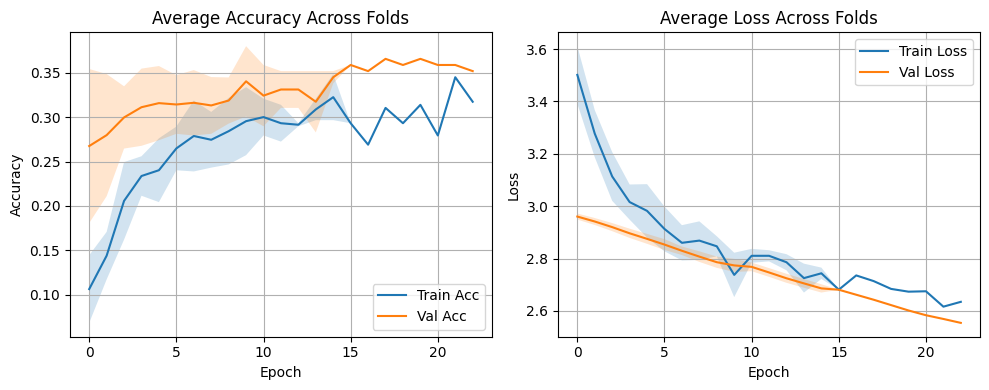

In [87]:
import numpy as np
import matplotlib.pyplot as plt

def plot_avg_learning_curves(test_metrics, save_dir):
    # collect all history dicts
    all_histories = [m["history"] for m in test_metrics]

    # determine longest training run
    max_epochs = max(len(h["accuracy"]) for h in all_histories)

    # pad histories to same length with np.nan
    def pad(metric_list, max_len):
        return [np.pad(m, (0, max_len - len(m)), constant_values=np.nan) for m in metric_list]

    train_accs = pad([np.array(h["accuracy"]) for h in all_histories], max_epochs)
    val_accs   = pad([np.array(h["val_accuracy"]) for h in all_histories], max_epochs)
    train_loss = pad([np.array(h["loss"]) for h in all_histories], max_epochs)
    val_loss   = pad([np.array(h["val_loss"]) for h in all_histories], max_epochs)

    # convert to arrays for mean/std
    train_accs = np.vstack(train_accs)
    val_accs   = np.vstack(val_accs)
    train_loss = np.vstack(train_loss)
    val_loss   = np.vstack(val_loss)

    epochs = np.arange(max_epochs)

    # plot accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, np.nanmean(train_accs, axis=0), label="Train Acc")
    plt.fill_between(epochs,
                     np.nanmean(train_accs, axis=0) - np.nanstd(train_accs, axis=0),
                     np.nanmean(train_accs, axis=0) + np.nanstd(train_accs, axis=0),
                     alpha=0.2)
    plt.plot(epochs, np.nanmean(val_accs, axis=0), label="Val Acc")
    plt.fill_between(epochs,
                     np.nanmean(val_accs, axis=0) - np.nanstd(val_accs, axis=0),
                     np.nanmean(val_accs, axis=0) + np.nanstd(val_accs, axis=0),
                     alpha=0.2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Average Accuracy Across Folds")
    plt.legend()
    plt.grid(True)

    # plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, np.nanmean(train_loss, axis=0), label="Train Loss")
    plt.fill_between(epochs,
                     np.nanmean(train_loss, axis=0) - np.nanstd(train_loss, axis=0),
                     np.nanmean(train_loss, axis=0) + np.nanstd(train_loss, axis=0),
                     alpha=0.2)
    plt.plot(epochs, np.nanmean(val_loss, axis=0), label="Val Loss")
    plt.fill_between(epochs,
                     np.nanmean(val_loss, axis=0) - np.nanstd(val_loss, axis=0),
                     np.nanmean(val_loss, axis=0) + np.nanstd(val_loss, axis=0),
                     alpha=0.2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Average Loss Across Folds")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "avg_learning_curves.jpg"), dpi=300, format="jpg")
    plt.show()

# run after training
plot_avg_learning_curves(test_metrics, FIGURES_DIR)

In [96]:
# train on full training data
model = build_model(input_shape=X_train_cnn.shape[1:], num_classes=NUM_CLASSES)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", min_delta=1e-4, patience=20, restore_best_weights=True, verbose=1
)
rlrop = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.25, patience=4, min_lr=1e-7, verbose=1
)

history = model.fit(
    X_train_cnn, y_train_encoded,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[es, rlrop],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 482ms/step - accuracy: 0.1112 - loss: 3.4694 - val_accuracy: 0.2045 - val_loss: 2.9622 - learning_rate: 5.0000e-04
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1763 - loss: 3.2381 - val_accuracy: 0.2273 - val_loss: 2.9306 - learning_rate: 5.0000e-04
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2290 - loss: 3.0156 - val_accuracy: 0.3182 - val_loss: 2.8931 - learning_rate: 5.0000e-04
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2509 - loss: 2.9839 - val_accuracy: 0.3409 - val_loss: 2.8529 - learning_rate: 5.0000e-04
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2666 - loss: 2.8818 - val_accuracy: 0.3182 - val_loss: 2.8111 - learning_rate: 5.0000e-04
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2876 - loss: 2.7253 - val_accuracy: 0.3182 - val_loss: 2.7698 - learning_rate: 5.0000e-04
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.294

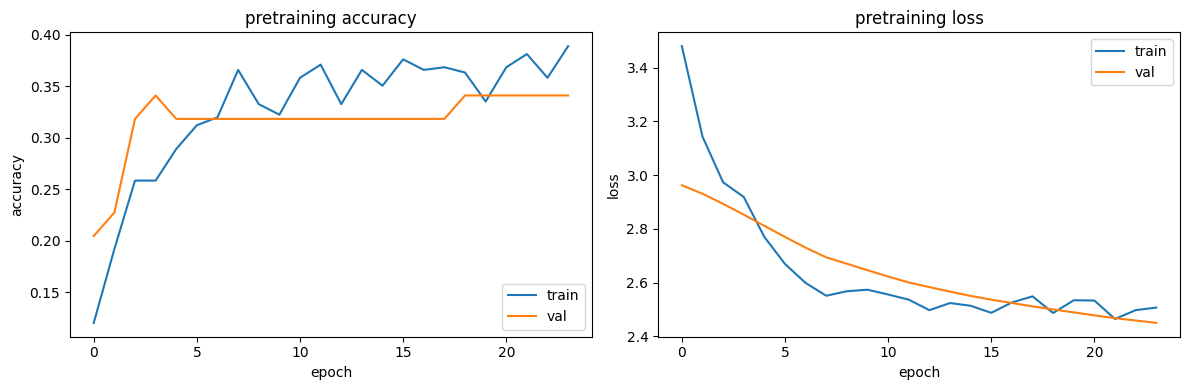

In [97]:
# plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('pretraining accuracy')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend(loc='lower right')

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('pretraining loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "pretraining_history.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [98]:
# save final model
model.save("outputs/models/final_model.keras")

In [99]:
# evaluate on test set
y_pred_prob = model.predict(X_test_cnn)
y_true = le.transform(y_test)
y_pred = np.argmax(y_pred_prob, axis=1)

y_bin = to_categorical(y_true, NUM_CLASSES)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
auc_macro = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='macro')
auc_micro = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='micro')

print(f"accuracy         : {acc:.4f}")
print(f"f1 (macro)       : {f1_macro:.4f}")
print(f"f1 (weighted)    : {f1_weighted:.4f}")
print(f"auc‑roc (macro)  : {auc_macro:.4f}")
print(f"auc‑roc (micro)  : {auc_micro:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step
accuracy         : 0.3265
f1 (macro)       : 0.0860
f1 (weighted)    : 0.1883
auc‑roc (macro)  : 0.8074
auc‑roc (micro)  : 0.8258


In [100]:
# classification report
print("classification report:")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0
))

classification report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.36      1.00      0.53        15
           3       0.00      0.00      0.00         4
           4       0.50      0.25      0.33         4
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         6
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         3

    accuracy                           0.33        49
   macro avg       0.09      0.12      0.09        49
weighted avg       0.15      0.33      0.19        49



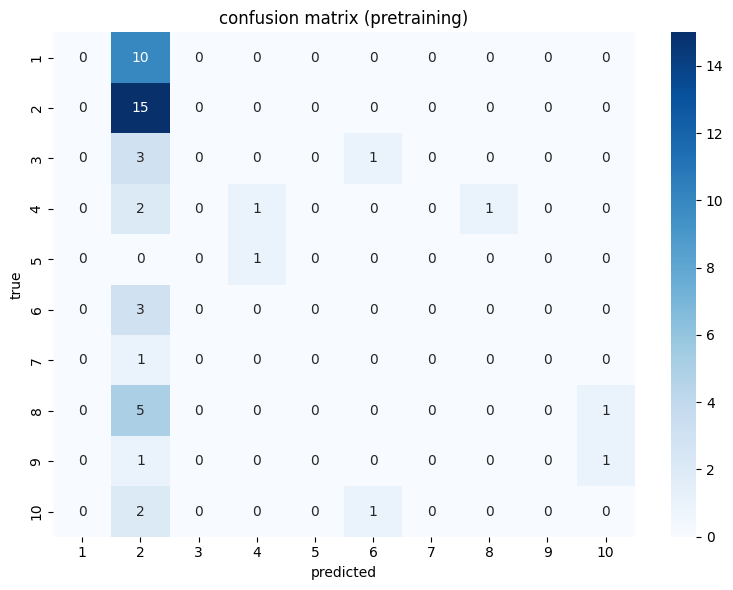

In [101]:
# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('confusion matrix (pretraining)')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "confusion_matrix_pretrain.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()
